# Purchase Intention Prediction

Objetivo:
Predecir si un usuario realizará una compra en un ecommerce según su comportamiento de navegación.

In [1]:
#Importación librerías

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


In [2]:
#Cargar dataset

df = pd.read_csv("../data/raw/data.csv")

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
#Muestra la info

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [4]:
#Muestra si hay nulos

df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [5]:
#Comprobar duplicados

df.duplicated().sum()

np.int64(125)

In [6]:
#Eliminar duplicados

df = df.drop_duplicates()

In [7]:
#Comprobar eliminación de duplicados

df.duplicated().sum()

np.int64(0)

In [8]:
df.to_csv("../data/processed/data.csv", index=False)

In [9]:
#Convertir target

df["Revenue"] = df["Revenue"].astype(int)

In [10]:
#Separar X e Y

X = df.drop("Revenue", axis=1)
y = df["Revenue"]

In [11]:
#Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y,random_state=42)

In [12]:
#separar columnas categóricas y numéricas

cat_cols = ["Month", "VisitorType", "Weekend"]

num_cols = [col for col in X.columns if col not in cat_cols]

In [13]:
#Preprocessing

preprocessor = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),("num", "passthrough", num_cols)])

In [14]:
#Pipeline

pipeline = ImbPipeline([("preprocessing", preprocessor), ("smote", SMOTE(random_state=42)), ("model", RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))])

In [15]:
#Entrenar

pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [16]:
#Predicciones

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]

In [17]:
#Evaluación 1

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      2059
           1       0.65      0.74      0.69       382

    accuracy                           0.90      2441
   macro avg       0.80      0.83      0.82      2441
weighted avg       0.90      0.90      0.90      2441



In [18]:
#Evaluación 2

print(confusion_matrix(y_test, y_pred))

[[1910  149]
 [ 101  281]]


In [19]:
#Evaluación 3

print("ROC-AUC:", roc_auc_score(y_test, y_proba))

ROC-AUC: 0.9301966338562156


In [20]:
#Métricas

classification_report
confusion_matrix
roc_auc_score

<function sklearn.metrics._ranking.roc_auc_score(y_true, y_score, *, average='macro', sample_weight=None, max_fpr=None, multi_class='raise', labels=None)>

In [21]:
#Feature importance

feature_names = pipeline.named_steps["preprocessing"].get_feature_names_out()

importances = pipeline.named_steps["model"].feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feat_imp = feat_imp.sort_values("importance", ascending=False)

feat_imp.head(10)

,feature,importance
23,num__PageValues,0.462355
7,cat__Month_Nov,0.080497
22,num__ExitRates,0.056931
20,num__ProductRelated_Duration,0.039241
15,num__Administrative,0.038229
6,cat__Month_May,0.035361
12,cat__VisitorType_Returning_Visitor,0.034481
16,num__Administrative_Duration,0.027338
10,cat__VisitorType_New_Visitor,0.025958
19,num__ProductRelated,0.025147


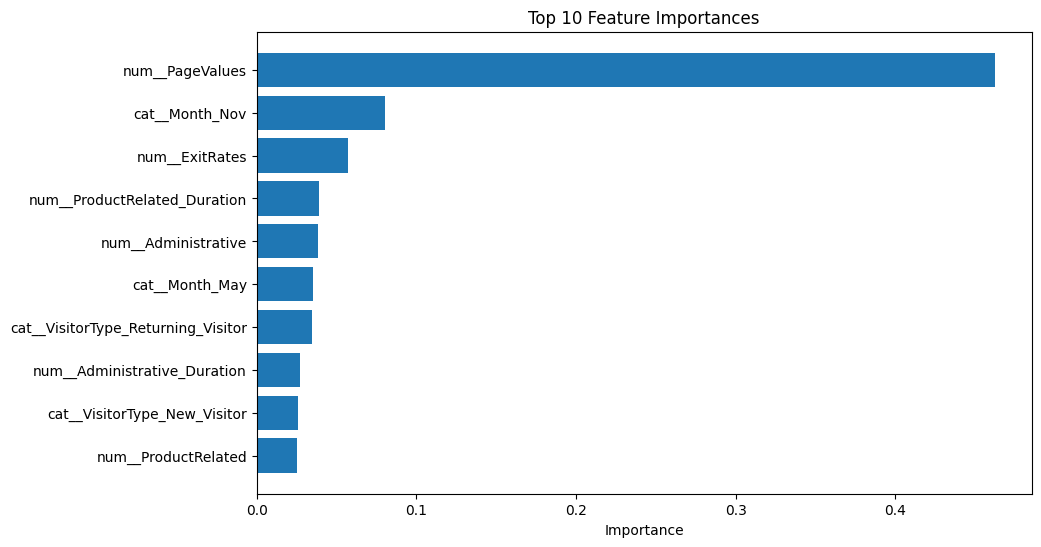

In [22]:
#Gráfica

import matplotlib.pyplot as plt

top_features = feat_imp.head(10)

plt.figure(figsize=(10,6))

plt.barh(top_features["feature"], top_features["importance"])

plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importances")

plt.xlabel("Importance")

plt.show()

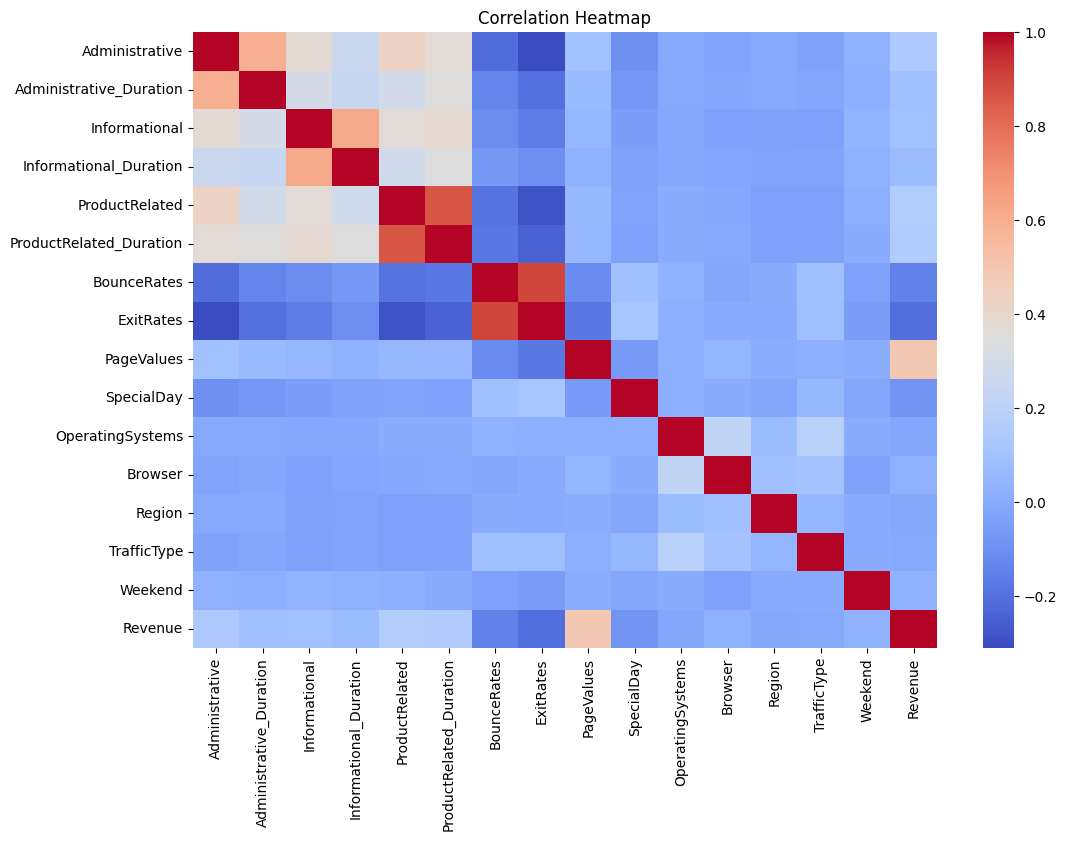

In [23]:
#Headmap de correlación

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

<Axes: xlabel='Revenue', ylabel='count'>

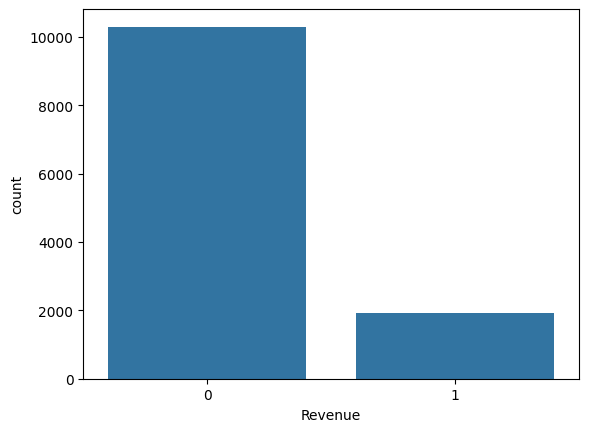

In [24]:
#Distribución target

sns.countplot(x=df["Revenue"])

In [25]:
#Guardar modelo
joblib.dump(pipeline, "../models/modelo_entrenado.pkl")


['../models/modelo_entrenado.pkl']